In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

df = pd.read_csv(r"MachineLearningRatingCleaned.csv", low_memory=False)

Feature Engineering for Insurance Risk & Pricing


In [17]:
# Vehicle-Based Features

# VehicleAge
df['VehicleAge'] = 2015 - df['RegistrationYear']

#Id Luxurey make
luxury_brands = ['MERCEDES-BENZ', 'BMW', 'AUDI', 'LEXUS']
df['IsLuxury'] = df['make'].isin(luxury_brands).astype(int)

#Power-to-Weight Ratio Estimate
df['PowerRatio'] = df['kilowatts'] / (df['cubiccapacity'] + 1)  # +1 to avoid divide by zero


In [16]:
# Policyholder Demographics

df['IsFemale'] = (df['Gender'] == 'Female').astype(int)
df['IsMarried'] = (df['MaritalStatus'] == 'Married').astype(int)

In [71]:
# Coverage and Plan Features

df['IsComprehensive'] = df['CoverType'].str.contains('Comprehensive', na=False).astype(int)
df['HasSecurityDevice'] = df[['TrackingDevice', 'AlarmImmobiliser']].apply(lambda x: int('Yes' in x.values), axis=1)
df['PremiumPerK'] = df['CalculatedPremiumPerTerm'] / (df['SumInsured'] / 1000)

In [15]:
# Geographic Features

# Is High Risk Province
high_risk_provinces = ['Gauteng', 'KwaZulu-Natal']
df['IsHighRiskProvince'] = df['Province'].isin(high_risk_provinces).astype(int)

# Zip Risk Score
zip_claim_rate = df.groupby('PostalCode')['TotalClaims'].mean()
df['ZipClaimRate'] = df['PostalCode'].map(zip_claim_rate)



In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)


Categorical columns: ['TransactionMonth', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'make', 'Model', 'bodytype', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'TermFrequency', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType']


In [ ]:
# One-Hot Encoding

df_encoded = pd.get_dummies(df, columns=[
    'Province', 'CoverType', 'CoverCategory', 'Language', 'Bank', 
    'AccountType', 'MaritalStatus', 'Gender', 'Country', 'VehicleType', 
    'make', 'Model', 'bodytype', 'Title', 'LegalType', 'TermFrequency'
], drop_first=True) 


In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

label_enc_cols = ['TermFrequency', 'TransactionMonth', 'Citizenship', 'SubCrestaZone' ]
label_enc = LabelEncoder()

for col in label_enc_cols:
    df[col] = label_enc.fit_transform(df[col].astype(str))
    

    

In [58]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['TotalClaims'])  # drop target column from features
y = df_encoded['TotalClaims']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (683075, 524)
Test set size: (170769, 524)


Linear Regression

In [56]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    all_data = pd.concat([X_train[col], X_test[col]], axis=0)
    le.fit(all_data.fillna("Missing"))

    X_train[col] = le.transform(X_train[col].fillna("Missing"))
    X_test[col] = le.transform(X_test[col].fillna("Missing"))
    
    
print(X_train.head())


        UnderwrittenCoverID  PolicyID  IsVATRegistered  Citizenship  \
625197                79494      6711            False            3   
686061               137332     11396            False            3   
314303               129034      7204            False            3   
354390                33707      2460            False            3   
110482                72783      5974            False            3   

        PostalCode  MainCrestaZone  SubCrestaZone  RegistrationYear  \
625197        8000               1              5              2006   
686061        4001               9             10              2013   
314303        7751               1              5              2010   
354390        7581               6             25              2014   
110482        2000               5             14              2010   

        Cylinders  cubiccapacity  ...  Section_Motor Comprehensive  \
625197        4.0         2237.0  ...                         True   
686061

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Filter data
df_claims = df[df['TotalClaims'] > 0].copy()

# Define features & target
X = df_claims.drop(columns=['TotalClaims', 'TotalPremium', 'PolicyID', 'UnderwrittenCoverID'])
y = df_claims['TotalClaims']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree model
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)

# Predict
y_pred = tree_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("🌳 Decision Tree - Claim Severity")
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))


🌳 Decision Tree - Claim Severity
RMSE: 31302.75
R²: 0.1915


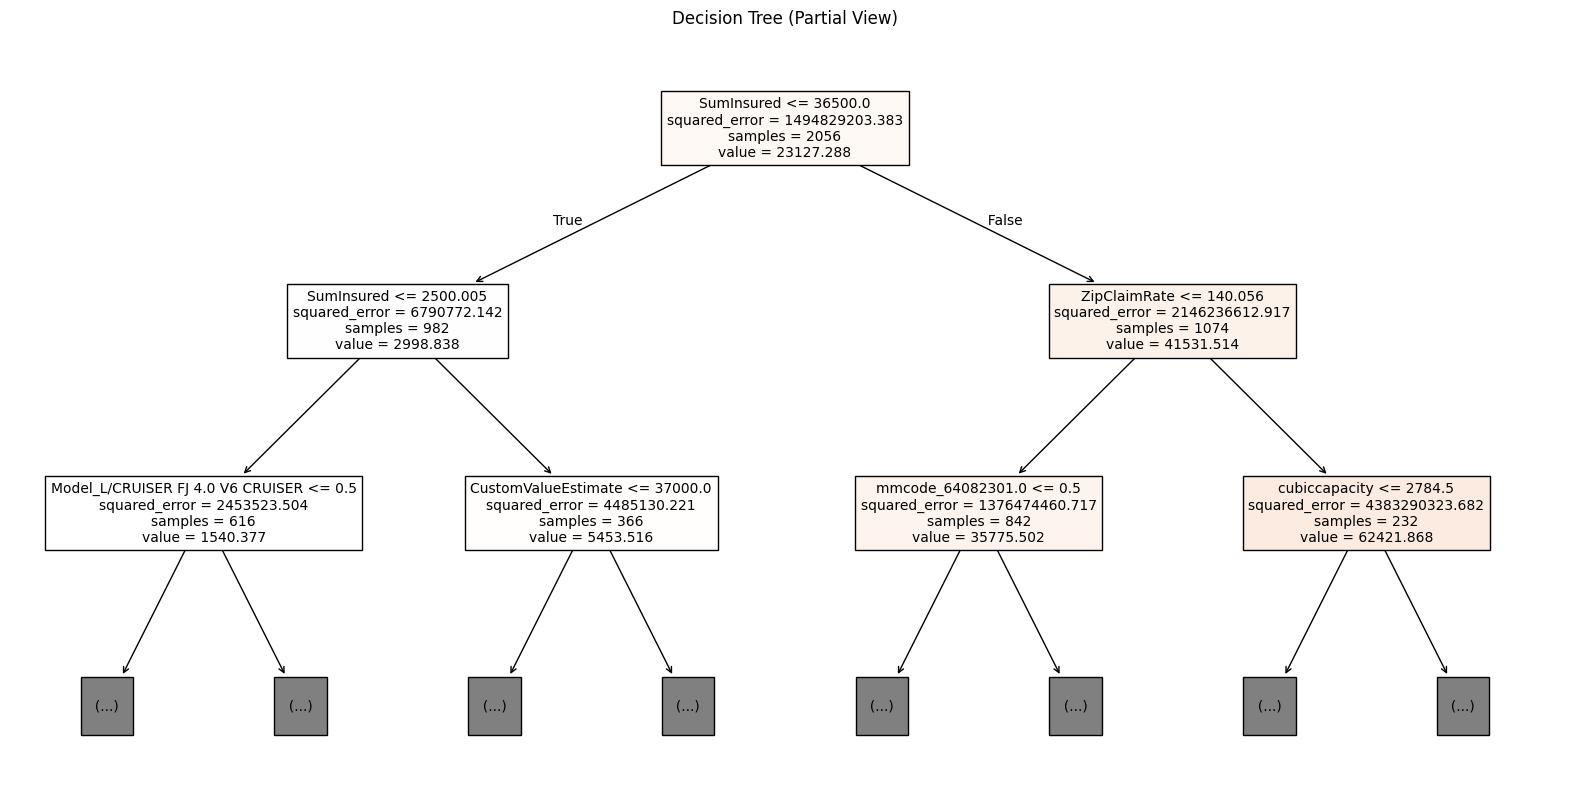

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=2, fontsize=10)
plt.title("Decision Tree (Partial View)")
plt.show()


In [ ]:
# Claim Severity Prediction (Random Forest)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Filter for claim cases
df_claims = df[df['TotalClaims'] > 0].copy()

# Features and target
X = df_claims.drop(columns=['TotalClaims', 'TotalPremium', 'PolicyID', 'UnderwrittenCoverID'])
y = df_claims['TotalClaims']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("🌲 Random Forest - Claim Severity")
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))


🌲 Random Forest - Claim Severity
RMSE: 29868.13
R²: 0.264


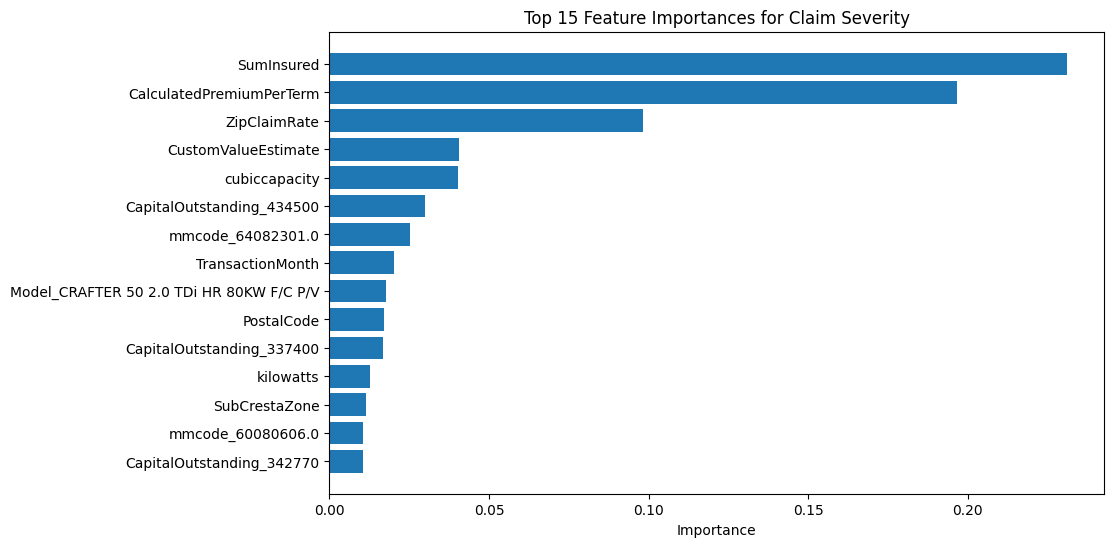

In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]  # top 15 features

plt.figure(figsize=(10,6))
plt.title("Top 15 Feature Importances for Claim Severity")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance")
plt.show()


In [ ]:
# Claim Severity Prediction (XGBoost)

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Filter data where TotalClaims > 0
df_claims = df[df['TotalClaims'] > 0].copy()

# Features and target
X = df_claims.drop(columns=['TotalClaims', 'TotalPremium', 'PolicyID', 'UnderwrittenCoverID'])
y = df_claims['TotalClaims']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("⚡ XGBoost - Claim Severity")
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))


⚡ XGBoost - Claim Severity
RMSE: 31014.55
R²: 0.2064


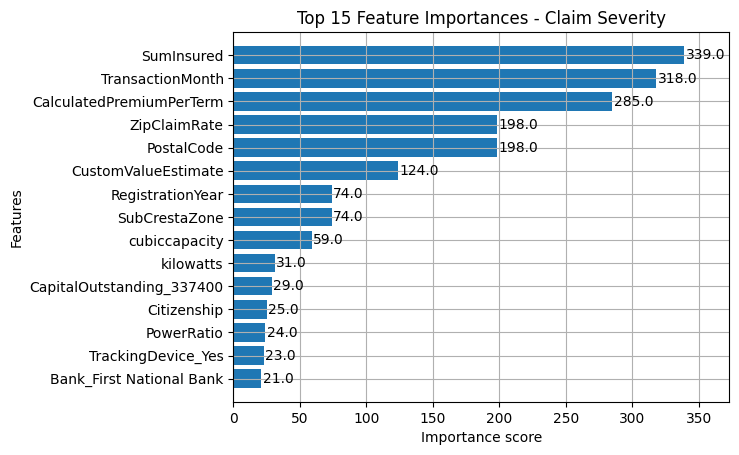

In [69]:
xgb.plot_importance(xgb_model, max_num_features=15, height=0.8)
plt.title("Top 15 Feature Importances - Claim Severity")
plt.show()

Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Create binary target: 1 if claim exists, else 0
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

# Define features and target
X_cls = df.drop(columns=['TotalClaims', 'TotalPremium', 'HasClaim', 'PolicyID', 'UnderwrittenCoverID'])
y_cls = df['HasClaim']

# One-hot encode categorical features
X_cls = pd.get_dummies(X_cls, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Use SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations)

c:\Users\Rahwa.B\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


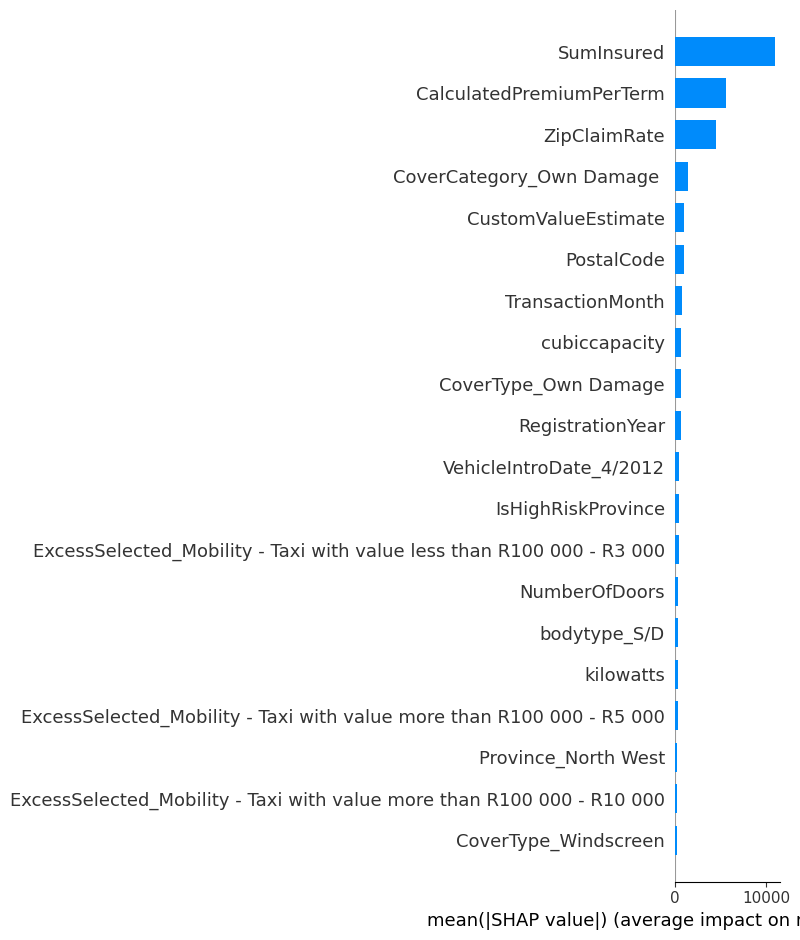

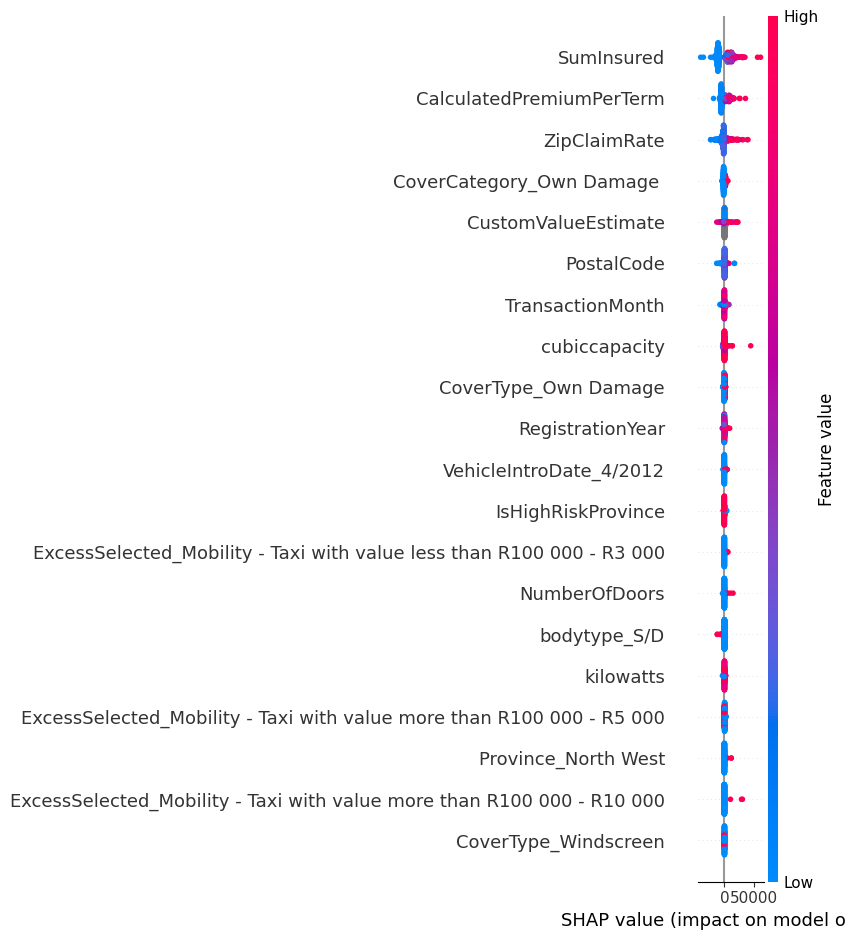

In [73]:
import shap
import matplotlib.pyplot as plt

# Use the trained XGBoost model (xgb_model) and training data X_train from before

# Create a SHAP explainer for tree models
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

# Summary plot: global feature importance & effect
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed summary plot: feature impact distribution
shap.summary_plot(shap_values, X_test)

# Choose one instance to explain (e.g., first test sample)
instance_idx = 0

# Force plot: explanation for one prediction (needs Jupyter notebook for interactive)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[instance_idx], X_test.iloc[instance_idx])
